In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [13]:
# Create directory for storing tables for downstream analysis
table_dir = Path("results/analysis_tables")
table_dir.mkdir(parents=True, exist_ok=True)

## Data preparation

In [14]:
# Load the results
df = pd.read_csv("results/results.csv")

# Shape should be 2 * 2 * (3 * 3 * 2 + 3) * 1000 = 84000
print(f"Shape: {df.shape}")
print(df.dtypes)

Shape: (84000, 13)
method                          str
replication_id                int64
ci_lower                    float64
ci_upper                    float64
bootstrap_seed                int64
library                         str
dgp                             str
statistic                       str
n                             int64
B                             int64
true_param_value            float64
nominal_1_sided_coverage    float64
nominal_2_sided_coverage    float64
dtype: object


In [15]:
df.head()

,method,replication_id,ci_lower,ci_upper,bootstrap_seed,library,dgp,statistic,n,B,true_param_value,nominal_1_sided_coverage,nominal_2_sided_coverage
0,percentile,0,0.009784,0.767302,2684470948,our,DGPNorm_0_1,mean,8,1000,0.0,0.975,0.95
1,percentile,1,-1.388232,-0.425091,4091952314,our,DGPNorm_0_1,mean,8,1000,0.0,0.975,0.95
2,percentile,2,-0.269031,0.655430,233227757,our,DGPNorm_0_1,mean,8,1000,0.0,0.975,0.95
3,percentile,3,-0.702347,0.180241,3276785861,our,DGPNorm_0_1,mean,8,1000,0.0,0.975,0.95
4,percentile,4,-0.077285,0.756373,3644269654,our,DGPNorm_0_1,mean,8,1000,0.0,0.975,0.95


In [16]:
# Create a pivot table to group the experiments ran under the same conditions (provided dataset, seed, ...)
paired = df.pivot(
    # Columns that uniquely identify each simulation run
    index=[
        "dgp",
        "statistic",
        "n",
        "B",
        "method",
        "replication_id",
        "bootstrap_seed",
        "true_param_value",
    ],
    # Columns to use to make the new frame's columns
    columns="library",
    # Columns to use to populate new frame's values
    values=["ci_lower", "ci_upper"],
)

# Rename the columns for easier access
paired.columns = ["_".join(part) for part in paired.columns]
paired = paired.reset_index()
paired

,dgp,statistic,n,B,method,replication_id,bootstrap_seed,true_param_value,ci_lower_our,ci_lower_ref,ci_upper_our,ci_upper_ref
0,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,0,2684470948,0.353553,-0.919196,-0.960065,0.942838,0.941861
1,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,1,4091952314,0.353553,-0.873240,-0.903344,0.946342,0.974207
2,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,2,233227757,0.353553,-0.882933,-0.848619,0.950405,0.937014
3,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,3,3276785861,0.353553,-0.664994,-0.830272,0.800456,0.809533
4,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,4,3644269654,0.353553,-0.850192,-0.648945,0.879428,0.840967
...,...,...,...,...,...,...,...,...,...,...,...,...
41995,DGPNorm_0_1,median,128,1000,percentile,995,111249246,0.000000,-0.136874,-0.191949,0.219589,0.231727
41996,DGPNorm_0_1,median,128,1000,percentile,996,746129938,0.000000,-0.157515,-0.161845,0.274976,0.275254
41997,DGPNorm_0_1,median,128,1000,percentile,997,3176734675,0.000000,-0.046484,-0.061066,0.365149,0.358169
41998,DGPNorm_0_1,median,128,1000,percentile,998,2924323672,0.000000,-0.264359,-0.193272,0.313570,0.324828


In [17]:
# Seems like 2 experiments out of 42000 failed to produce a valid CI using our library.
# The reference one may have produced valid CIs due to different random number handling.
paired.isna().sum()

dgp                 0
statistic           0
n                   0
B                   0
method              0
replication_id      0
bootstrap_seed      0
true_param_value    0
ci_lower_our        2
ci_lower_ref        0
ci_upper_our        2
ci_upper_ref        0
dtype: int64

In [18]:
# The culprit is Pearson correlation for n = 8 and percentile method. Since
# computation can lead to division by 0 variance.
has_missing_endpoint = paired.isna().any(axis=1)
paired[has_missing_endpoint]

,dgp,statistic,n,B,method,replication_id,bootstrap_seed,true_param_value,ci_lower_our,ci_lower_ref,ci_upper_our,ci_upper_ref
1505,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,percentile,505,1077415524,0.353553,NaN,-0.308126,NaN,0.792564
1655,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,percentile,655,1123490515,0.353553,NaN,-0.814943,NaN,0.932868


In [19]:
# Since it only happened in 2/1000 experiments for that setup, we will remove these results.
paired_clean = paired.dropna().copy()
# We are left with 41998 rows
paired_clean

,dgp,statistic,n,B,method,replication_id,bootstrap_seed,true_param_value,ci_lower_our,ci_lower_ref,ci_upper_our,ci_upper_ref
0,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,0,2684470948,0.353553,-0.919196,-0.960065,0.942838,0.941861
1,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,1,4091952314,0.353553,-0.873240,-0.903344,0.946342,0.974207
2,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,2,233227757,0.353553,-0.882933,-0.848619,0.950405,0.937014
3,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,3,3276785861,0.353553,-0.664994,-0.830272,0.800456,0.809533
4,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,4,3644269654,0.353553,-0.850192,-0.648945,0.879428,0.840967
...,...,...,...,...,...,...,...,...,...,...,...,...
41995,DGPNorm_0_1,median,128,1000,percentile,995,111249246,0.000000,-0.136874,-0.191949,0.219589,0.231727
41996,DGPNorm_0_1,median,128,1000,percentile,996,746129938,0.000000,-0.157515,-0.161845,0.274976,0.275254
41997,DGPNorm_0_1,median,128,1000,percentile,997,3176734675,0.000000,-0.046484,-0.061066,0.365149,0.358169
41998,DGPNorm_0_1,median,128,1000,percentile,998,2924323672,0.000000,-0.264359,-0.193272,0.313570,0.324828


## Coverage analysis

In [20]:
# Compute coverage indicators for all interval types and both libraries
def covers_param(df, whose):
    df[f"lower_covers_{whose}"] = (
        df[f"ci_lower_{whose}"] <= df["true_param_value"]
    )
    df[f"upper_covers_{whose}"] = (
        df["true_param_value"] <= df[f"ci_upper_{whose}"]
    )
    df[f"two_sided_covers_{whose}"] = (
        df[f"lower_covers_{whose}"] & df[f"upper_covers_{whose}"]
    )


covers_param(paired_clean, "our")
covers_param(paired_clean, "ref")

paired_clean

,dgp,statistic,n,B,method,replication_id,bootstrap_seed,true_param_value,ci_lower_our,ci_lower_ref,ci_upper_our,ci_upper_ref,lower_covers_our,upper_covers_our,two_sided_covers_our,lower_covers_ref,upper_covers_ref,two_sided_covers_ref
0,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,0,2684470948,0.353553,-0.919196,-0.960065,0.942838,0.941861,True,True,True,True,True,True
1,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,1,4091952314,0.353553,-0.873240,-0.903344,0.946342,0.974207,True,True,True,True,True,True
2,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,2,233227757,0.353553,-0.882933,-0.848619,0.950405,0.937014,True,True,True,True,True,True
3,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,3,3276785861,0.353553,-0.664994,-0.830272,0.800456,0.809533,True,True,True,True,True,True
4,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,4,3644269654,0.353553,-0.850192,-0.648945,0.879428,0.840967,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,DGPNorm_0_1,median,128,1000,percentile,995,111249246,0.000000,-0.136874,-0.191949,0.219589,0.231727,True,True,True,True,True,True
41996,DGPNorm_0_1,median,128,1000,percentile,996,746129938,0.000000,-0.157515,-0.161845,0.274976,0.275254,True,True,True,True,True,True
41997,DGPNorm_0_1,median,128,1000,percentile,997,3176734675,0.000000,-0.046484,-0.061066,0.365149,0.358169,True,True,True,True,True,True
41998,DGPNorm_0_1,median,128,1000,percentile,998,2924323672,0.000000,-0.264359,-0.193272,0.313570,0.324828,True,True,True,True,True,True


In [21]:
coverage_summary = (
    paired_clean.groupby(by=["dgp", "statistic", "method", "n"])
    .agg(
        lower_coverage_our=("lower_covers_our", "mean"),
        lower_coverage_ref=("lower_covers_ref", "mean"),
        upper_coverage_our=("upper_covers_our", "mean"),
        upper_coverage_ref=("upper_covers_ref", "mean"),
        two_sided_coverage_our=("two_sided_covers_our", "mean"),
        two_sided_coverage_ref=("two_sided_covers_ref", "mean"),
        repetitions=("replication_id", "count"),
    )
    .reset_index()
)

coverage_summary["lower_coverage_diff"] = (
    coverage_summary["lower_coverage_our"]
    - coverage_summary["lower_coverage_ref"]
)
coverage_summary["upper_coverage_diff"] = (
    coverage_summary["upper_coverage_our"]
    - coverage_summary["upper_coverage_ref"]
)
coverage_summary["two_sided_coverage_diff"] = (
    coverage_summary["two_sided_coverage_our"]
    - coverage_summary["two_sided_coverage_ref"]
)

coverage_summary

,dgp,statistic,method,n,lower_coverage_our,lower_coverage_ref,upper_coverage_our,upper_coverage_ref,two_sided_coverage_our,two_sided_coverage_ref,repetitions,lower_coverage_diff,upper_coverage_diff,two_sided_coverage_diff
0,DGPBiNorm-1_1_2.0_0.5_1.0,corr,double,8,0.995000,0.997000,0.998000,0.995000,0.993000,0.9920,1000,-0.002,0.003000,0.001000
1,DGPBiNorm-1_1_2.0_0.5_1.0,corr,double,32,0.980000,0.983000,0.982000,0.979000,0.962000,0.9620,1000,-0.003,0.003000,0.000000
2,DGPBiNorm-1_1_2.0_0.5_1.0,corr,double,128,0.971000,0.968000,0.966000,0.966000,0.937000,0.9340,1000,0.003,0.000000,0.003000
3,DGPBiNorm-1_1_2.0_0.5_1.0,corr,percentile,8,0.932866,0.932866,0.967936,0.966934,0.900802,0.8998,998,0.000,0.001002,0.001002
4,DGPBiNorm-1_1_2.0_0.5_1.0,corr,percentile,32,0.962000,0.960000,0.974000,0.974000,0.936000,0.9340,1000,0.002,0.000000,0.002000
5,DGPBiNorm-1_1_2.0_0.5_1.0,corr,percentile,128,0.964000,0.963000,0.972000,0.963000,0.936000,0.9260,1000,0.001,0.009000,0.010000
6,DGPExp_1,mean,double,8,0.997000,0.997000,0.927000,0.928000,0.924000,0.9250,1000,0.000,-0.001000,-0.001000
7,DGPExp_1,mean,double,32,0.979000,0.979000,0.971000,0.971000,0.950000,0.9500,1000,0.000,0.000000,0.000000
8,DGPExp_1,mean,double,128,0.971000,0.975000,0.972000,0.967000,0.943000,0.9420,1000,-0.004,0.005000,0.001000
9,DGPExp_1,mean,percentile,8,0.991000,0.990000,0.855000,0.852000,0.846000,0.8420,1000,0.001,0.003000,0.004000


In [22]:
coverage_summary.to_csv(table_dir / "results_coverage_summary.csv", index=False)

In [23]:
# What are the differences in coverage like in general for different interval
# types
def get_diff_summary_by_method(df, bound):
    return (
        # Group rows by method and only select the bound column
        df.groupby("method")[bound]
        .agg(
            mean_difference="mean",
            mean_absolute_difference=lambda x: x.abs().mean(),
            median_absolute_difference=lambda x: x.abs().median(),
            p90_absolute_difference=lambda x: x.abs().quantile(0.90),
            p95_absolute_difference=lambda x: x.abs().quantile(0.95),
            p99_absolute_difference=lambda x: x.abs().quantile(0.99),
            max_absolute_difference=lambda x: x.abs().max(),
        )
        .T
    )

In [24]:
# Lower coverage
get_diff_summary_by_method(coverage_summary, "lower_coverage_diff")

method,double,percentile
mean_difference,-0.001095,0.001476
mean_absolute_difference,0.002714,0.002238
median_absolute_difference,0.003000,0.002000
p90_absolute_difference,0.005000,0.004000
p95_absolute_difference,0.006000,0.006000
p99_absolute_difference,0.006000,0.006000
max_absolute_difference,0.006000,0.006000


In [25]:
# Upper coverage
get_diff_summary_by_method(coverage_summary, "upper_coverage_diff")

method,double,percentile
mean_difference,0.000762,0.000524
mean_absolute_difference,0.001810,0.002333
median_absolute_difference,0.002000,0.002000
p90_absolute_difference,0.003000,0.004000
p95_absolute_difference,0.004000,0.004000
p99_absolute_difference,0.004800,0.008000
max_absolute_difference,0.005000,0.009000


In [26]:
# Two sided coverage
get_diff_summary_by_method(coverage_summary, "two_sided_coverage_diff")

method,double,percentile
mean_difference,-0.000333,0.002000
mean_absolute_difference,0.002333,0.003905
median_absolute_difference,0.001000,0.004000
p90_absolute_difference,0.006000,0.009000
p95_absolute_difference,0.007000,0.009000
p99_absolute_difference,0.008600,0.009800
max_absolute_difference,0.009000,0.010000


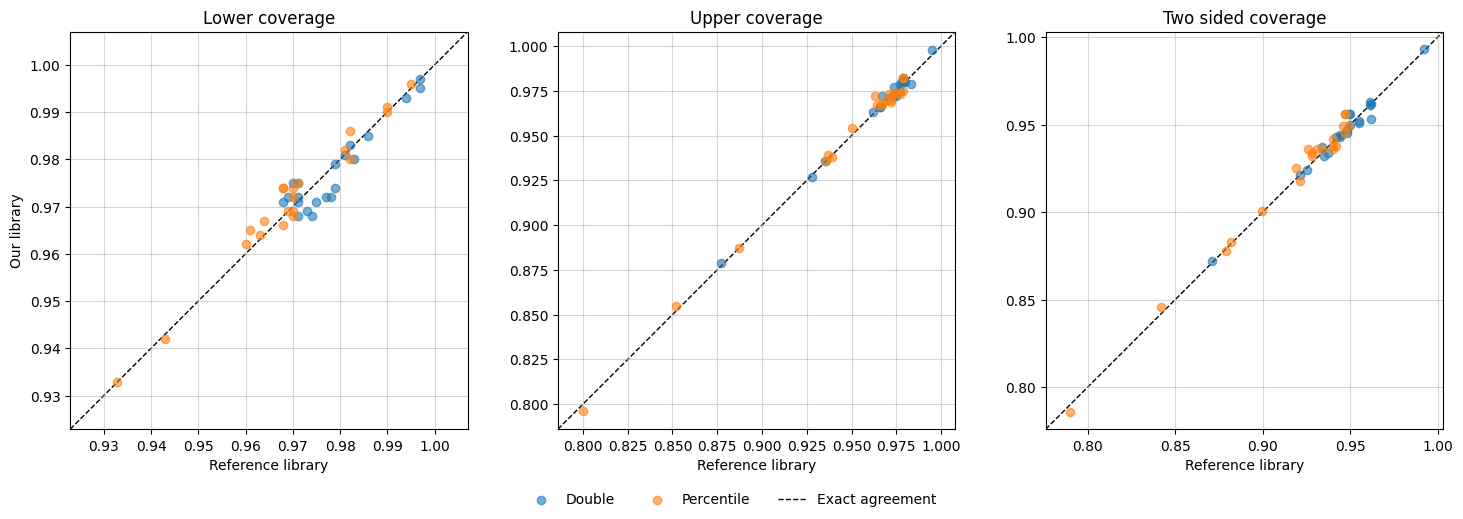

In [27]:
# Plot the coverage agreement of the libraries
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

for j, coverage in enumerate(
    ["lower_coverage", "upper_coverage", "two_sided_coverage"]
):
    x = coverage_summary[f"{coverage}_ref"]
    y = coverage_summary[f"{coverage}_our"]

    for method in ("double", "percentile"):
        our_coverage = coverage_summary[(coverage_summary["method"] == method)][
            f"{coverage}_our"
        ].to_numpy()
        ref_coverage = coverage_summary[(coverage_summary["method"] == method)][
            f"{coverage}_ref"
        ].to_numpy()

        ax[j].scatter(
            ref_coverage,
            our_coverage,
            alpha=0.6,
            label=method.capitalize(),
            zorder=2,
        )

    lower_limit = min(x.min(), y.min()) - 0.01
    upper_limit = max(x.max(), y.max()) + 0.01

    ax[j].set(
        xlim=(lower_limit, upper_limit),
        ylim=(lower_limit, upper_limit),
        xlabel="Reference library",
        aspect="equal",
    )

    if j == 0:
        ax[j].set_ylabel("Our library")

    ax[j].set_title(
        f"{coverage.replace('_', ' ').capitalize()}",
    )

    ax[j].plot(
        (lower_limit, upper_limit),
        (lower_limit, upper_limit),
        color="black",
        linestyle="--",
        linewidth=1,
        label="Exact agreement",
        zorder=1,
    )

    ax[j].grid(alpha=0.5)

handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3,
    frameon=False,
)

fig.tight_layout(rect=[0, 0.10, 1, 1])

In [28]:
# The difference in coverage of both libraries seems to be near zero.
# Compute CIs for the difference in order to quantify uncertinaty.

# Use a mature bootstrap implementation
from scipy.stats import bootstrap

# Since experiments are paired, we compute differences between libraries
# so we can only resample those
paired_clean["coverage_diff_lower"] = paired_clean["lower_covers_our"].astype(
    int
) - paired_clean["lower_covers_ref"].astype(int)

paired_clean["coverage_diff_upper"] = paired_clean["upper_covers_our"].astype(
    int
) - paired_clean["upper_covers_ref"].astype(int)

paired_clean["coverage_diff_two_sided"] = paired_clean[
    "two_sided_covers_our"
].astype(int) - paired_clean["two_sided_covers_ref"].astype(int)

In [32]:
# These values define different experiment configurations -> for each
# configuration, we want to report uncertainty in the difference in coverages
group_cols = ["dgp", "statistic", "n", "method"]

results = []

for group_values, group_df in paired_clean.groupby(group_cols):
    # store metadata
    row = {col: val for col, val in zip(group_cols, group_values)}

    for coverage_type in ["lower", "upper", "two_sided"]:
        coverage_diff = group_df[f"coverage_diff_{coverage_type}"]

        # CI for difference in converage for the current experiment
        cd_ci = bootstrap(
            (coverage_diff,),
            np.mean,
            n_resamples=10_000,
            confidence_level=0.95,
            method="BCa",
            rng=np.random.default_rng(0),
        )

        low, high = cd_ci.confidence_interval

        row[f"{coverage_type}_coverage_diff"] = np.mean(coverage_diff)

        row[f"{coverage_type}_coverage_diff_CI_low"] = low
        row[f"{coverage_type}_coverage_diff_CI_high"] = high

    results.append(row)

coverage_ci_df = pd.DataFrame(results)

In [38]:
coverage_ci_df.to_csv(table_dir / "results_coverage_ci.csv", index=False)

In [30]:
def does_not_contain_0(df):
    mask = np.zeros(len(df), dtype=bool)

    for bound in ["lower", "upper", "two_sided"]:
        mask = (
            mask
            | (df[f"{bound}_coverage_diff_CI_low"] > 0)
            | (df[f"{bound}_coverage_diff_CI_high"] < 0)
        )

    return mask

In [31]:
coverage_ci_double = coverage_ci_df[
    coverage_ci_df["method"] == "double"
].reset_index(drop=True)

coverage_ci_double

,dgp,statistic,n,method,lower_coverage_diff,lower_coverage_diff_CI_low,lower_coverage_diff_CI_high,upper_coverage_diff,upper_coverage_diff_CI_low,upper_coverage_diff_CI_high,two_sided_coverage_diff,two_sided_coverage_diff_CI_low,two_sided_coverage_diff_CI_high
0,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,double,-0.002,-0.007,0.002000,0.003,-0.001,0.008,0.001,-0.006,0.007
1,DGPBiNorm-1_1_2.0_0.5_1.0,corr,32,double,-0.003,-0.008,0.001000,0.003,-0.001,0.008,0.000,-0.006,0.006
2,DGPBiNorm-1_1_2.0_0.5_1.0,corr,128,double,0.003,-0.003,0.009000,0.000,-0.007,0.007,0.003,-0.006,0.012
3,DGPExp_1,mean,8,double,0.000,-0.003,0.003000,-0.001,-0.009,0.007,-0.001,-0.009,0.007
4,DGPExp_1,mean,32,double,0.000,-0.007,0.006878,0.000,-0.006,0.005,0.000,-0.009,0.008
5,DGPExp_1,mean,128,double,-0.004,-0.011,0.002000,0.005,-0.002,0.013,0.001,-0.009,0.011
6,DGPExp_1,median,8,double,-0.005,-0.012,0.000000,-0.004,-0.012,0.004,-0.009,-0.019,0.001
7,DGPExp_1,median,32,double,-0.006,-0.013,-0.001000,0.003,-0.003,0.010,-0.003,-0.012,0.005
8,DGPExp_1,median,128,double,0.001,-0.004,0.007000,-0.002,-0.008,0.003,-0.001,-0.009,0.007
9,DGPLogNorm_0_1,mean,8,double,-0.001,-0.005,0.002000,0.002,-0.006,0.010,0.001,-0.007,0.010


In [86]:
mask = does_not_contain_0(coverage_ci_double)

coverage_ci_double[mask]

,dgp,statistic,n,method,lower_coverage_diff,lower_coverage_diff_CI_low,lower_coverage_diff_CI_high,upper_coverage_diff,upper_coverage_diff_CI_low,upper_coverage_diff_CI_high,two_sided_coverage_diff,two_sided_coverage_diff_CI_low,two_sided_coverage_diff_CI_high
7,DGPExp_1,median,32,double,-0.006,-0.013,-0.001,0.003,-0.003,0.010,-0.003,-0.012,0.005
13,DGPLogNorm_0_1,median,32,double,-0.005,-0.011,-0.001,0.002,-0.003,0.008,-0.003,-0.011,0.004
14,DGPLogNorm_0_1,median,128,double,0.005,0.001,0.011,0.002,-0.002,0.007,0.007,0.001,0.015
19,DGPNorm_0_1,median,32,double,-0.006,-0.013,-0.001,0.002,-0.003,0.008,-0.004,-0.013,0.004


In [87]:
coverage_ci_percentile = coverage_ci_df[
    coverage_ci_df["method"] == "percentile"
].reset_index(drop=True)

coverage_ci_percentile

,dgp,statistic,n,method,lower_coverage_diff,lower_coverage_diff_CI_low,lower_coverage_diff_CI_high,upper_coverage_diff,upper_coverage_diff_CI_low,upper_coverage_diff_CI_high,two_sided_coverage_diff,two_sided_coverage_diff_CI_low,two_sided_coverage_diff_CI_high
0,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,percentile,0.000,-0.007014,0.007014,0.001002,-0.003006,0.006012,0.001002,-0.007014,0.01002
1,DGPBiNorm-1_1_2.0_0.5_1.0,corr,32,percentile,0.002,-0.004000,0.009000,0.000000,-0.003000,0.003000,0.002000,-0.005000,0.00900
2,DGPBiNorm-1_1_2.0_0.5_1.0,corr,128,percentile,0.001,-0.004000,0.006000,0.009000,0.004000,0.017000,0.010000,0.003000,0.01900
3,DGPExp_1,mean,8,percentile,0.001,0.000000,0.006000,0.003000,-0.004000,0.011000,0.004000,-0.003000,0.01200
4,DGPExp_1,mean,32,percentile,-0.002,-0.007000,0.000000,-0.001000,-0.006000,0.004000,-0.003000,-0.009000,0.00200
5,DGPExp_1,mean,128,percentile,0.001,-0.003000,0.006000,0.004000,0.000000,0.010000,0.005000,-0.001000,0.01200
6,DGPExp_1,median,8,percentile,0.003,-0.002000,0.009000,0.003000,0.001000,0.008615,0.006000,0.001000,0.01300
7,DGPExp_1,median,32,percentile,0.000,-0.004000,0.004000,0.002000,-0.001000,0.007000,0.002000,-0.003000,0.00800
8,DGPExp_1,median,128,percentile,0.002,0.000000,0.007000,-0.004000,-0.010000,0.000000,-0.002000,-0.008000,0.00300
9,DGPLogNorm_0_1,mean,8,percentile,0.000,-0.004000,0.004000,-0.004000,-0.010939,0.001000,-0.004000,-0.011000,0.00300


In [88]:
mask = does_not_contain_0(coverage_ci_percentile)

coverage_ci_percentile[mask]

,dgp,statistic,n,method,lower_coverage_diff,lower_coverage_diff_CI_low,lower_coverage_diff_CI_high,upper_coverage_diff,upper_coverage_diff_CI_low,upper_coverage_diff_CI_high,two_sided_coverage_diff,two_sided_coverage_diff_CI_low,two_sided_coverage_diff_CI_high
2,DGPBiNorm-1_1_2.0_0.5_1.0,corr,128,percentile,0.001,-0.004,0.006,0.009,0.004,0.017000,0.010,0.003,0.019
6,DGPExp_1,median,8,percentile,0.003,-0.002,0.009,0.003,0.001,0.008615,0.006,0.001,0.013
14,DGPLogNorm_0_1,median,128,percentile,0.006,0.001,0.013,0.003,0.001,0.009000,0.009,0.003,0.017
20,DGPNorm_0_1,median,128,percentile,0.006,0.001,0.013,0.003,0.001,0.009000,0.009,0.003,0.017


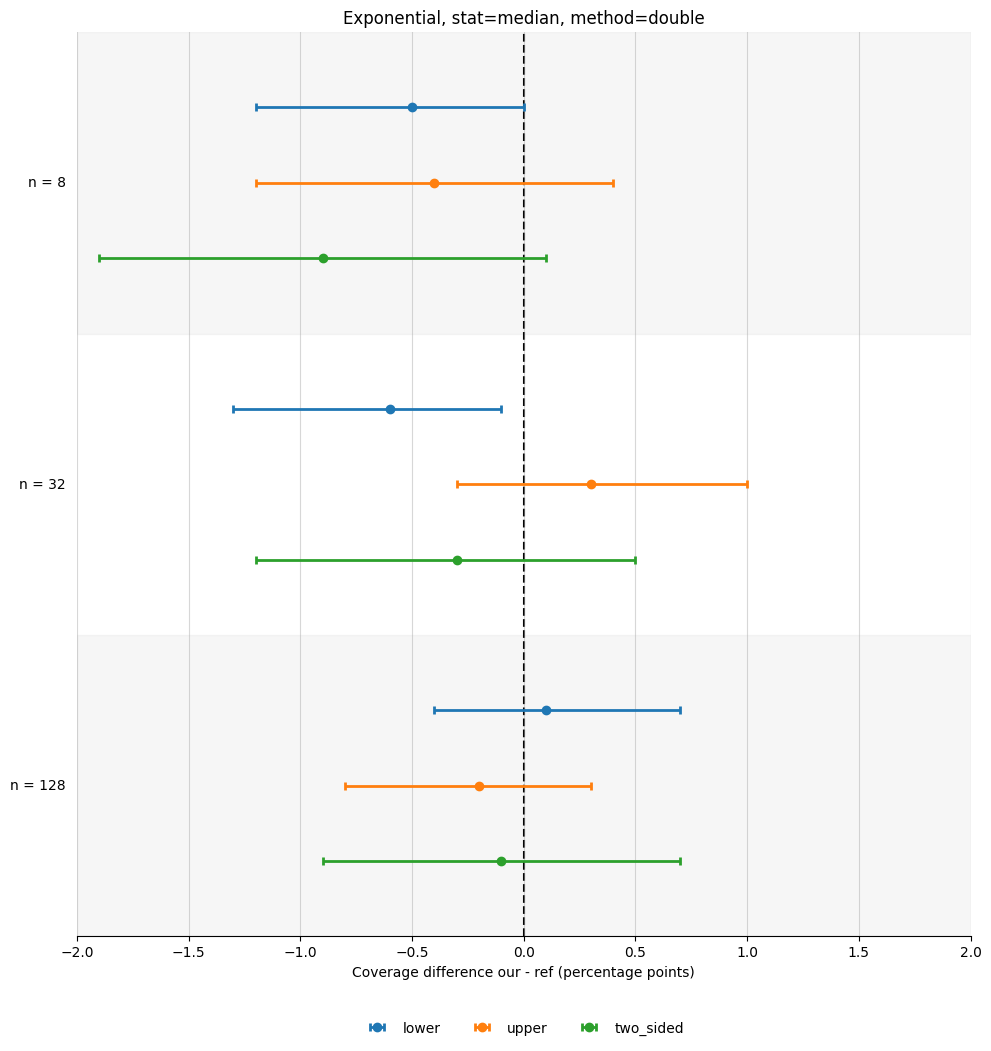

In [93]:
group_cols = [
    "dgp",
    "statistic",
    "n",
    "method",
]

plot_df = coverage_ci_df.copy()

# Convert coverage differences and CIs to percentage points
plot_df[
    ["lower_coverage_diff", "upper_coverage_diff", "two_sided_coverage_diff"]
] *= 100
for bound in ["lower", "upper", "two_sided"]:
    plot_df[
        [f"{bound}_coverage_diff_CI_low", f"{bound}_coverage_diff_CI_high"]
    ] *= 100


def plot_results(
    dgp_name,
    statistic,
    method,
):
    dgp_map = {
        "normal": "DGPNorm_0_1",
        "bivariate normal": "DGPBiNorm-1_1_2.0_0.5_1.0",
        "exponential": "DGPExp_1",
        "lognormal": "DGPLogNorm_0_1",
    }
    dgp = dgp_map[dgp_name]

    df_subset = plot_df[
        (plot_df["dgp"] == dgp)
        & (plot_df["statistic"] == statistic)
        & (plot_df["method"] == method)
    ]

    ns = df_subset["n"].unique()

    # 3 groups (lower, upper and two_sided)
    centers = [5, 3, 1]

    fig, ax = plt.subplots(figsize=(10, 10))

    ax.set_title(f"{dgp_name.capitalize()}, stat={statistic}, method={method}")

    bound_to_color = {
        "lower": "tab:blue",
        "upper": "tab:orange",
        "two_sided": "tab:green",
    }

    for n, y in zip(ns, centers):
        for bound in bound_to_color.keys():
            data_row = df_subset[df_subset["n"] == n]

            coverage_diff = data_row[f"{bound}_coverage_diff"]
            low = data_row[f"{bound}_coverage_diff_CI_low"]
            high = data_row[f"{bound}_coverage_diff_CI_high"]

            if bound == "lower":
                height = y + 0.5
            elif bound == "two_sided":
                height = y - 0.5
            else:
                height = y

            # Erorrbars for all bounds (lower, upper, two_sided)
            ax.errorbar(
                x=coverage_diff,
                xerr=(coverage_diff - low, high - coverage_diff),
                y=height,
                elinewidth=2,
                capsize=3,
                capthick=2,
                ecolor=bound_to_color[bound],
                color=bound_to_color[bound],
                fmt="o",
                zorder=2,
                label=bound,
            )

    ax.set_xlim(-2, 2)
    ax.set_ylim(0, 6)
    ax.axvline(0, linestyle="--", color="black", zorder=1, linewidth=1.5)
    ax.set_xlabel("Coverage difference our - ref (percentage points)")
    ax.set_ylabel("Sample size")
    ax.set_yticks(centers, ns)

    for i, spine in enumerate(ax.spines.values()):
        if i != 2:
            spine.set_visible(False)

    ax.grid(alpha=0.5)
    ax.yaxis.set_visible(False)

    for y_pos, n in zip(centers, ns):
        ax.text(
            -2.05,
            y_pos,
            f"n = {n}",
            ha="right",
            va="center",
            clip_on=False,
        )

    for i, center in enumerate(centers):
        if i % 2 == 0:
            ax.axhspan(
                center - 1,
                center + 1,
                alpha=0.20,
                zorder=0,
                color="lightgray",
            )

    fig.tight_layout()

    handles, labels = ax.get_legend_handles_labels()

    unique = dict(zip(labels, handles))

    ax.legend(
        unique.values(),
        unique.keys(),
        loc="upper center",
        bbox_to_anchor=(0.5, -0.08),
        ncol=3,
        frameon=False,
    )


plot_results("exponential", "median", "double")

## Endpoint analysis

In [39]:
# Compute endpoint differences
endpoint_df = paired_clean.copy()

endpoint_df["ci_lower_diff"] = (
    endpoint_df["ci_lower_our"] - endpoint_df["ci_lower_ref"]
)
endpoint_df["ci_upper_diff"] = (
    endpoint_df["ci_upper_our"] - endpoint_df["ci_upper_ref"]
)

In [40]:
def summary(endpoint):
    return (
        endpoint_df.groupby("method")[f"ci_{endpoint}_diff"]
        .agg(
            mean_diff="mean",
            mean_absolute_diff=lambda x: x.abs().mean(),
            median_absolute_diff=lambda x: x.abs().median(),
            p90_absolute_diff=lambda x: x.abs().quantile(0.90),
            p95_absolute_diff=lambda x: x.abs().quantile(0.95),
            p99_absolute_diff=lambda x: x.abs().quantile(0.99),
            max_absolute_diff=lambda x: x.abs().max(),
        )
        .T
    )

In [41]:
# Lower endpoint
summary("lower")

method,double,percentile
mean_diff,0.003727,-0.000506
mean_absolute_diff,0.032709,0.020573
median_absolute_diff,0.014084,0.009380
p90_absolute_diff,0.073037,0.045922
p95_absolute_diff,0.122450,0.071938
p99_absolute_diff,0.333599,0.192846
max_absolute_diff,1.625690,0.985969


In [42]:
# Upper endpoint
summary("upper")

method,double,percentile
mean_diff,0.008790,-0.001509
mean_absolute_diff,0.082932,0.029883
median_absolute_diff,0.019621,0.010306
p90_absolute_diff,0.176766,0.060666
p95_absolute_diff,0.333675,0.106539
p99_absolute_diff,1.054167,0.353853
max_absolute_diff,16.565349,4.649276


In [43]:
# The maximum absolute endpoint difference for the double method is approx. 16.6 for the upper endpoint.
# See which experiment lead to this discrepancy.
double_endpoint_df = endpoint_df[endpoint_df["method"] == "double"]

discrepancy_row = double_endpoint_df[
    double_endpoint_df["ci_upper_diff"].abs()
    == double_endpoint_df["ci_upper_diff"].abs().max()
]
discrepancy_row[
    [
        "dgp",
        "statistic",
        "n",
        "method",
        "replication_id",
        "bootstrap_seed",
        "true_param_value",
        "ci_upper_our",
        "ci_upper_ref",
    ]
]

,dgp,statistic,n,method,replication_id,bootstrap_seed,true_param_value,ci_upper_our,ci_upper_ref
24437,DGPLogNorm_0_1,median,8,double,437,3218085765,1.0,18.61513,2.04978


In [44]:
# Try to reproduce this experiment
import bootstrap_ci as boot
from comparison import seed_numba
from generators import DGPLogNorm

from bootstrap_diagnostics import Bootstrap, IIDResampler

# Same setup as in comparison.py
seed = 0
dgp = DGPLogNorm(seed, 0, 1)

n = discrepancy_row["n"].item()
B = discrepancy_row["B"].item()
replication_id = discrepancy_row["replication_id"].item()
random_seed = discrepancy_row["bootstrap_seed"].item()

sample_sizes = [8, 32, 128]
sample_sizes = double_endpoint_df["n"].unique()

# Get through the different sample sizes for the mean
for ni in sample_sizes:
    dgp.sample(sample_size=ni, nr_samples=1000)

sample = dgp.sample(sample_size=n, nr_samples=1000)[replication_id]

resampler = IIDResampler(sample)
bs = Bootstrap(
    np.median,
    resampler,
    vectorized=True,
)

ci_our = bs.double_percentile_ci(
    confidence_level=0.95,
    side="two",
    n_jobs=-1,
    b1_resamples=B,
    b2_resamples=B,
    seed=random_seed,
)
ci_our

ConfidenceInterval(estimate=array(1.38418679), confidence_level=0.95, side='two', lower=array(0.40724131), upper=array(18.61512991))

In [45]:
# We reproduced our result
np.allclose(
    ci_our.lower, discrepancy_row["ci_lower_our"], atol=1e-10, rtol=0
) and np.allclose(
    ci_our.upper, discrepancy_row["ci_upper_our"], atol=1e-10, rtol=0
)

True

In [46]:
from numba import njit

bts = boot.Bootstrap(sample, np.median, use_jit=True)

seed_numba(random_seed)
ci_ref = bts.ci(
    [0.025, 0.975],
    side="one",
    method="double",
    nr_bootstrap_samples=B,
    seed=random_seed,
)
ci_ref

array([0.40724131, 2.0497805 ])

In [47]:
# We reproduced the result for the reference library
np.allclose(
    ci_ref,
    discrepancy_row[["ci_lower_ref", "ci_upper_ref"]],
    atol=1e-10,
    rtol=0,
)

True

In [48]:
# The sample contains an outlier
sample.max()

np.float64(35.772478335376604)

In [49]:
from scipy.stats import lognorm

# Probability of drawing such value or larger:
# mu = 0 -> exp(mu) = 1
dist = lognorm(loc=0, scale=1, s=1)

# Drawing such a value from the DGP is quite unlikely
print(
    f"Probability of drawing the outlier or something larger: {dist.sf(sample.max())}"
)

# Probability of maximum in sample of 8 observations being as large or larger (given that draws are independent)
print(
    f"Probability of drawing a sequence with the maximum as large or larger: {1 - dist.cdf(sample.max()) ** n}"
)
# However, running the experiment 1000x this is not as unlikely as it first seems
print(
    f"Probability that at least one experiment out of 1000 contains such or greater maximum: {(1 - dist.cdf(sample.max()) ** (n * 1000))}"
)

Probability of drawing the outlier or something larger: 0.00017366127959725532
Probability of drawing a sequence with the maximum as large or larger: 0.001388446099283569
Probability that at least one experiment out of 1000 contains such or greater maximum: 0.7507779178177564


In [50]:
# But it turns out we can get close to our result by using a different seed
# This seems to be caused by the sample.
bts = boot.Bootstrap(sample, np.median, use_jit=True)

# Need to call this for seed to be used
seed_numba(random_seed + 12)
upper_bound_ref = bts.ci(
    [0.975],
    side="one",
    method="double",
    nr_bootstrap_samples=B,
    seed=random_seed + 12,
)
# We got an even larger upper bound
upper_bound_ref

array([18.90317559])

In [51]:
# Analyze uncertainty of endpoint differences using the bootstrap
group_cols = ["dgp", "statistic", "n", "method"]

result = []

for group_values, group_df in endpoint_df.groupby(group_cols):
    row = {col: val for col, val in zip(group_cols, group_values)}

    for bound in ["lower", "upper"]:
        # We will bootstrap the mean bound difference for each experiment
        bound_diff = group_df[f"ci_{bound}_diff"]

        bd_ci = bootstrap(
            (bound_diff,),
            np.mean,
            n_resamples=10_000,
            confidence_level=0.95,
            method="BCa",
            rng=np.random.default_rng(0),
        )

        low, high = bd_ci.confidence_interval
        row[f"{bound}_mean_diff"] = np.mean(bound_diff)
        row[f"{bound}_mean_diff_CI_low"] = low
        row[f"{bound}_mean_diff_CI_high"] = high

    result.append(row)

diff_df = pd.DataFrame(result)

diff_df

,dgp,statistic,n,method,lower_mean_diff,lower_mean_diff_CI_low,lower_mean_diff_CI_high,upper_mean_diff,upper_mean_diff_CI_low,upper_mean_diff_CI_high
0,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,double,-0.001329,-0.012718,0.010584,-0.001407,-0.004959,0.002133
1,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,percentile,-0.000679,-0.005736,0.004338,-0.000190,-0.002423,0.002029
2,DGPBiNorm-1_1_2.0_0.5_1.0,corr,32,double,0.000669,-0.001961,0.003246,0.000610,-0.000841,0.002112
3,DGPBiNorm-1_1_2.0_0.5_1.0,corr,32,percentile,-0.001240,-0.002578,0.000165,-0.000547,-0.001435,0.000352
4,DGPBiNorm-1_1_2.0_0.5_1.0,corr,128,double,-0.000417,-0.001342,0.000546,-0.000091,-0.000802,0.000611
5,DGPBiNorm-1_1_2.0_0.5_1.0,corr,128,percentile,-0.000093,-0.000737,0.000553,0.000006,-0.000495,0.000517
6,DGPExp_1,mean,8,double,0.001470,-0.001831,0.004884,0.001829,-0.011457,0.015204
7,DGPExp_1,mean,8,percentile,-0.000558,-0.002290,0.001071,0.001079,-0.001616,0.003815
8,DGPExp_1,mean,32,double,0.000003,-0.001343,0.001362,0.001894,-0.003085,0.006852
9,DGPExp_1,mean,32,percentile,-0.000032,-0.001047,0.000984,-0.000687,-0.002260,0.000882


In [53]:
diff_df.to_csv(table_dir / "results_endpoint_mean_diff.csv", index=False)

In [54]:
def does_not_contain_0_endpoint_diff(df):
    mask = np.zeros(len(df), dtype=bool)

    for bound in ["lower", "upper"]:
        mask = (
            mask
            | (df[f"{bound}_mean_diff_CI_low"] > 0)
            | (df[f"{bound}_mean_diff_CI_high"] < 0)
        )

    return mask

In [55]:
mask = does_not_contain_0_endpoint_diff(diff_df)

# It seems like our bounds tend to be shifted slightly more to the right.
# I believe this is the result of using a different prepivoting strategy (using <= instead of <).
# Our calibrated probability is larger which means we select a larger calibrated level for both bounds,
# leading to our intervals being shifted to the right slightly
diff_df[mask]

,dgp,statistic,n,method,lower_mean_diff,lower_mean_diff_CI_low,lower_mean_diff_CI_high,upper_mean_diff,upper_mean_diff_CI_low,upper_mean_diff_CI_high
12,DGPExp_1,median,8,double,0.002667,-0.000553,0.005792,0.030954,0.007772,0.054551
14,DGPExp_1,median,32,double,0.008891,0.006983,0.010946,0.018176,0.014569,0.021891
16,DGPExp_1,median,128,double,0.003008,0.002094,0.003962,0.004321,0.002973,0.005663
24,DGPLogNorm_0_1,median,8,double,0.005341,0.001442,0.009430,0.033145,-0.048481,0.117795
26,DGPLogNorm_0_1,median,32,double,0.011271,0.008989,0.013585,0.027311,0.021914,0.032809
28,DGPLogNorm_0_1,median,128,double,0.003530,0.002361,0.004716,0.004830,0.003094,0.006602
30,DGPNorm_0_1,mean,8,double,0.008907,0.001246,0.016533,0.003427,-0.004187,0.011439
34,DGPNorm_0_1,mean,128,double,0.000963,0.000051,0.001884,-0.000668,-0.001577,0.000277
36,DGPNorm_0_1,median,8,double,0.012097,-0.000018,0.024200,0.014601,0.003405,0.026440
38,DGPNorm_0_1,median,32,double,0.016685,0.013194,0.020151,0.017616,0.014224,0.021133


## Two sided interval length analysis

In [56]:
# Analyze the width of the two-sided intervals
length_df = endpoint_df.copy()

length_df["len_our"] = length_df["ci_upper_our"] - length_df["ci_lower_our"]
length_df["len_ref"] = length_df["ci_upper_ref"] - length_df["ci_lower_ref"]

length_df["len_diff"] = length_df["len_our"] - length_df["len_ref"]

# We will analyze relative length differences (in percentages) because they are more informative
length_df["rel_len_diff"] = length_df["len_diff"] / length_df["len_ref"] * 100

length_df

,dgp,statistic,n,B,method,replication_id,bootstrap_seed,true_param_value,ci_lower_our,ci_lower_ref,...,two_sided_covers_ref,coverage_diff_lower,coverage_diff_upper,coverage_diff_two_sided,ci_lower_diff,ci_upper_diff,len_our,len_ref,len_diff,rel_len_diff
0,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,0,2684470948,0.353553,-0.919196,-0.960065,...,True,0,0,0,0.040870,0.000977,1.862034,1.901926,-0.039892,-2.097468
1,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,1,4091952314,0.353553,-0.873240,-0.903344,...,True,0,0,0,0.030104,-0.027864,1.819582,1.877551,-0.057969,-3.087468
2,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,2,233227757,0.353553,-0.882933,-0.848619,...,True,0,0,0,-0.034314,0.013391,1.833338,1.785633,0.047705,2.671621
3,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,3,3276785861,0.353553,-0.664994,-0.830272,...,True,0,0,0,0.165278,-0.009077,1.465450,1.639805,-0.174355,-10.632650
4,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,4,3644269654,0.353553,-0.850192,-0.648945,...,True,0,0,0,-0.201247,0.038461,1.729620,1.489912,0.239708,16.088717
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,DGPNorm_0_1,median,128,1000,percentile,995,111249246,0.000000,-0.136874,-0.191949,...,True,0,0,0,0.055075,-0.012138,0.356462,0.423676,-0.067213,-15.864319
41996,DGPNorm_0_1,median,128,1000,percentile,996,746129938,0.000000,-0.157515,-0.161845,...,True,0,0,0,0.004330,-0.000278,0.432491,0.437099,-0.004608,-1.054202
41997,DGPNorm_0_1,median,128,1000,percentile,997,3176734675,0.000000,-0.046484,-0.061066,...,True,0,0,0,0.014583,0.006980,0.411633,0.419235,-0.007602,-1.813420
41998,DGPNorm_0_1,median,128,1000,percentile,998,2924323672,0.000000,-0.264359,-0.193272,...,True,0,0,0,-0.071088,-0.011258,0.577930,0.518100,0.059830,11.547928


In [57]:
def length_diff_summary(df):
    return (
        df.groupby("method")["rel_len_diff"]
        .agg(
            mean_rel_length_diff="mean",
            median_rel_length_diff="median",
            mean_abs_rel_length_diff=lambda x: x.abs().mean(),
            median_abs_rel_length_diff=lambda x: x.abs().median(),
            q90_rel_length_diff=lambda x: x.quantile(0.90),
            q95_rel_length_diff=lambda x: x.quantile(0.95),
            q99_rel_length_diff=lambda x: x.quantile(0.99),
            max_rel_length_diff=lambda x: x.max(),
            min_rel_length_diff=lambda x: x.min(),
        )
        .T
    )


In [58]:
length_diff_summary(length_df)

method,double,percentile
mean_rel_length_diff,1.491305,0.163090
median_rel_length_diff,0.000000,0.000000
mean_abs_rel_length_diff,8.727138,4.187900
median_abs_rel_length_diff,5.668911,2.788081
q90_rel_length_diff,13.962206,6.478831
q95_rel_length_diff,20.119407,9.451775
q99_rel_length_diff,47.796211,21.054559
max_rel_length_diff,1150.765833,100.275475
min_rel_length_diff,-92.516408,-50.749494


In [59]:
# Analyze which distribution caused such large length difference
# The maximum relative length difference is approx. 1150 %. See what caused this
length_df_double = length_df[length_df["method"] == "double"]

discrepancy_row = length_df_double[
    length_df_double["rel_len_diff"] == length_df_double["rel_len_diff"].max()
]
# Again lognormal with sample size 8
discrepancy_row[
    [
        "dgp",
        "statistic",
        "n",
        "method",
        "replication_id",
        "bootstrap_seed",
        "true_param_value",
        "ci_lower_our",
        "ci_lower_ref",
        "ci_upper_our",
        "ci_upper_ref",
    ]
]

,dgp,statistic,n,method,replication_id,bootstrap_seed,true_param_value,ci_lower_our,ci_lower_ref,ci_upper_our,ci_upper_ref
24068,DGPLogNorm_0_1,median,8,double,68,2910179760,1.0,0.315077,0.315077,13.88228,1.399788


In [60]:
# Try to reproduce the extreme result
seed = 0
dgp = DGPLogNorm(seed, 0, 1)

n = discrepancy_row["n"].item()
B = discrepancy_row["B"].item()
replication_id = discrepancy_row["replication_id"].item()
random_seed = discrepancy_row["bootstrap_seed"].item()

sample_sizes = [8, 32, 128]
sample_sizes = double_endpoint_df["n"].unique()

# Get through it for the mean
for ni in sample_sizes:
    dgp.sample(sample_size=ni, nr_samples=1000)

sample = dgp.sample(sample_size=n, nr_samples=1000)[replication_id]

In [61]:
# We can again see that the sample contains a large outlier
sample.max()

np.float64(26.46872934144097)

In [62]:
resampler = IIDResampler(sample)
bts = Bootstrap(np.median, resampler, True)

ci_our = bts.double_percentile_ci(
    0.95,
    "two",
    B,
    B,
    n_jobs=-1,
    seed=random_seed,
)

low = ci_our.lower
high = ci_our.upper

# We reproduced the result for our implementation
np.allclose(
    low, discrepancy_row["ci_lower_our"], atol=1e-10, rtol=0
) and np.allclose(high, discrepancy_row["ci_upper_our"])

True

In [63]:
bts = boot.Bootstrap(sample, np.median, True)
seed_numba(random_seed)
ci_ref = bts.ci(
    [0.025, 0.975], method="double", nr_bootstrap_samples=B, seed=random_seed
)

# Reproduced the reference result
np.allclose(
    ci_ref,
    discrepancy_row[["ci_lower_ref", "ci_upper_ref"]],
    atol=1e-10,
    rtol=0,
)

True

In [64]:
# Setting a different seed for the reference implementation
seed_numba(random_seed + 12)
bts = boot.Bootstrap(sample, np.median, True)
ci_ref = bts.ci(
    [0.025, 0.975],
    method="double",
    nr_bootstrap_samples=B,
    seed=random_seed + 12,
)

# Again a large upper bound much closer to our CI
ci_ref

array([ 0.3150768 , 13.85906171])

In [65]:
# Bootstrap relative length differences
result = []

for group_values, group_df in length_df.groupby(group_cols):
    row = {col: val for col, val in zip(group_cols, group_values)}

    # We will bootstrap the mean bound difference to see whether
    rel_len_diff = group_df["rel_len_diff"]

    rld_ci = bootstrap(
        (rel_len_diff,),
        np.mean,
        n_resamples=10_000,
        confidence_level=0.95,
        method="BCa",
        rng=np.random.default_rng(0),
    )

    low, high = rld_ci.confidence_interval
    row["mean_rel_len_diff"] = rel_len_diff.mean()
    row["mean_rel_len_diff_CI_low"] = low
    row["mean_rel_len_diff_CI_high"] = high

    result.append(row)

rel_len_diff_df = pd.DataFrame(result)
rel_len_diff_df

,dgp,statistic,n,method,mean_rel_len_diff,mean_rel_len_diff_CI_low,mean_rel_len_diff_CI_high
0,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,double,1.249140,0.293212,2.302760
1,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,percentile,0.303014,-0.169017,0.829480
2,DGPBiNorm-1_1_2.0_0.5_1.0,corr,32,double,0.381459,-0.158351,0.940836
3,DGPBiNorm-1_1_2.0_0.5_1.0,corr,32,percentile,0.204249,-0.071846,0.477577
4,DGPBiNorm-1_1_2.0_0.5_1.0,corr,128,double,0.480534,-0.025405,0.979992
5,DGPBiNorm-1_1_2.0_0.5_1.0,corr,128,percentile,0.130216,-0.126306,0.402375
6,DGPExp_1,mean,8,double,1.006785,0.267189,1.763726
7,DGPExp_1,mean,8,percentile,0.192059,-0.054910,0.439972
8,DGPExp_1,mean,32,double,0.684185,0.030048,1.346488
9,DGPExp_1,mean,32,percentile,0.022827,-0.248760,0.305325


In [67]:
rel_len_diff_df.to_csv(table_dir / "results_mean_rel_len_diff.csv", index=False)

In [68]:
mask = (rel_len_diff_df["mean_rel_len_diff_CI_low"] > 0) | (
    rel_len_diff_df["mean_rel_len_diff_CI_high"] < 0
)

# Our two sided intervals seem to be wider on average for the double method (especially for medians of right skewed distributions).
# Does this mean that we produce wider intervals more often than the reference library in individual cases?
rel_len_diff_df[mask]

,dgp,statistic,n,method,mean_rel_len_diff,mean_rel_len_diff_CI_low,mean_rel_len_diff_CI_high
0,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,double,1.249140,0.293212,2.302760
6,DGPExp_1,mean,8,double,1.006785,0.267189,1.763726
8,DGPExp_1,mean,32,double,0.684185,0.030048,1.346488
12,DGPExp_1,median,8,double,5.434757,3.708470,7.531956
14,DGPExp_1,median,32,double,1.918428,1.260931,2.616102
16,DGPExp_1,median,128,double,0.730101,0.180853,1.288683
18,DGPLogNorm_0_1,mean,8,double,1.049992,0.321692,1.782094
20,DGPLogNorm_0_1,mean,32,double,1.135738,0.411063,1.877096
24,DGPLogNorm_0_1,median,8,double,10.380013,6.402889,16.360019
26,DGPLogNorm_0_1,median,32,double,2.455434,1.712514,3.272518


In [69]:
# This could be cause by prepivoting differences but the previous results might
# be slightly misleading since a few large relative length differences due to
# prepivoting might cause the mean to be much larger.
# Use a small tolerance
def diff_summary(x, metadata, tol=1e-12):
    wider = x > tol
    narrower = x < -tol
    equal = x.abs() <= tol

    return {
        **metadata,
        "proportion_wider": wider.mean(),
        "proportion_equal": equal.mean(),
        "proportion_narrower": narrower.mean(),
        "mean": np.mean(x),
        "median": np.median(x),
        "q90": x.quantile(0.90),
        "q95": x.quantile(0.95),
        "q99": x.quantile(0.99),
        "Pr(our_wider)-Pr(ref_wider)": wider.mean() - narrower.mean(),
    }


result = []
for group_values, group_df in length_df.groupby(group_cols)["rel_len_diff"]:
    row = {col: val for col, val in zip(group_cols, group_values)}
    result.append(diff_summary(group_df, row))

two_sided_summary = pd.DataFrame(result)

# We see that the proportion of wider intervals is very similar to the proportion of narrower intervals.
# When our intervals are wider, they tend to be much wider, but they are not wider more often than
# they are narrower as it seems.
two_sided_summary[two_sided_summary["method"] == "double"]


,dgp,statistic,n,method,proportion_wider,proportion_equal,proportion_narrower,mean,median,q90,q95,q99,Pr(our_wider)-Pr(ref_wider)
0,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,double,0.490,0.000,0.510,1.249140,-0.101395,14.028258,25.041906,56.336531,-0.020
2,DGPBiNorm-1_1_2.0_0.5_1.0,corr,32,double,0.497,0.000,0.503,0.381459,-0.018635,11.783896,14.940777,22.766852,-0.006
4,DGPBiNorm-1_1_2.0_0.5_1.0,corr,128,double,0.510,0.000,0.490,0.480534,0.336728,10.950433,14.227568,19.545734,0.020
6,DGPExp_1,mean,8,double,0.503,0.000,0.497,1.006785,0.135698,16.386694,22.493608,31.466817,0.006
8,DGPExp_1,mean,32,double,0.511,0.000,0.489,0.684185,0.337465,13.667266,17.170119,28.928292,0.022
10,DGPExp_1,mean,128,double,0.491,0.000,0.509,0.216474,-0.234140,12.429901,16.581908,22.562444,-0.018
12,DGPExp_1,median,8,double,0.365,0.285,0.350,5.434757,0.000000,28.574547,55.094746,148.407279,0.015
14,DGPExp_1,median,32,double,0.515,0.037,0.448,1.918428,0.231850,14.587074,21.050785,35.752756,0.067
16,DGPExp_1,median,128,double,0.490,0.007,0.503,0.730101,-0.043127,11.719632,16.146777,26.979599,-0.013
18,DGPLogNorm_0_1,mean,8,double,0.506,0.000,0.494,1.049992,0.163168,16.760321,20.826860,34.408350,0.012


In [70]:
# Let's analyze:
# Pr(wider_our) - Pr(wider_ref)
# (Is for each experiment, the probability that our library produces wider intervals larger than the probability that our library produces narrower intervals than the reference library).

tol = 1e-12

# -1: ref wider, 1: our wider, 0: both same width effectively
length_df["wider"] = np.select(
    [length_df["rel_len_diff"] < -tol, length_df["rel_len_diff"] > tol],
    [-1, 1],
    default=0,
)

proportion_results = []

for group_values, group_df in length_df.groupby(group_cols)["wider"]:
    row = {col: val for col, val in zip(group_cols, group_values)}

    w_ci = bootstrap(
        (group_df,),
        np.mean,
        n_resamples=10_000,
        confidence_level=0.95,
        method="BCa",
        rng=np.random.default_rng(0),
    )

    low, high = w_ci.confidence_interval
    row["Pr(our_wider)-Pr(ref_wider)"] = np.mean(group_df)
    row["wider_CI_low"] = low
    row["wider_CI_high"] = high

    proportion_results.append(row)

results_wider = pd.DataFrame(proportion_results)

In [ ]:
results_wider.to_csv(table_dir / "results_wider.csv", index=False)

In [149]:
results_wider[results_wider["method"] == "double"]

,dgp,statistic,n,method,Pr(our_wider)-Pr(ref_wider),wider_CI_low,wider_CI_high
0,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,double,-0.020,-0.080,0.040000
2,DGPBiNorm-1_1_2.0_0.5_1.0,corr,32,double,-0.006,-0.068,0.056000
4,DGPBiNorm-1_1_2.0_0.5_1.0,corr,128,double,0.020,-0.042,0.084000
6,DGPExp_1,mean,8,double,0.006,-0.056,0.068000
8,DGPExp_1,mean,32,double,0.022,-0.040,0.086000
10,DGPExp_1,mean,128,double,-0.018,-0.080,0.044000
12,DGPExp_1,median,8,double,0.015,-0.038,0.068000
14,DGPExp_1,median,32,double,0.067,0.007,0.127000
16,DGPExp_1,median,128,double,-0.013,-0.074,0.049000
18,DGPLogNorm_0_1,mean,8,double,0.012,-0.050,0.074000


In [ ]:
# Only the CI for median of Exponential(1) with n=32 doesn't contain 0. Given our experiments,
# we cannot conclude that our method produces wider intervals more often than the reference
# library.
mask = ~(
    (results_wider["wider_CI_low"] <= 0) & (results_wider["wider_CI_high"] >= 0)
)
results_wider[mask]

,dgp,statistic,n,method,Pr(our_wider)-Pr(ref_wider),wider_CI_low,wider_CI_high
14,DGPExp_1,median,32,double,0.067,0.007,0.127
